In [ ]:
pip install -r requirements.txt

In [1]:
import sqlite3
import json
import os
from datetime import datetime
from typing import TypedDict, Optional, List, Dict, Any
from enum import Enum
import re

# LangGraph imports
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent

# LangChain imports
#from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# Database setup
DB_PATH = "/Users/vijendra/agentic-ai-usecases/advanced/flight-booking-assistant/indigo_airline.db"

def get_db_connection():
    """Create and return a database connection"""
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    return conn

# Verify database exists
if os.path.exists(DB_PATH):
    print(f"✅ Database found at: {DB_PATH}")
    conn = get_db_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print(f"✅ Database contains {len(tables)} tables:")
    for table in tables:
        print(f"  - {table[0]}")
    conn.close()
else:
    print(f"❌ Database not found at: {DB_PATH}")

# Airport code mapping
AIRPORT_CODES = {
    'jaipur': 'JAI',
    'mumbai': 'BOM',
    'delhi': 'DEL',
    'bangalore': 'BLR',
    'hyderabad': 'HYD',
    'kolkata': 'CCU',
    'kochi': 'COK',
    'pune': 'PNQ',
}

AIRPORT_NAMES = {
    'JAI': 'Jaipur International Airport',
    'BOM': 'Chhatrapati Shivaji International Airport',
    'DEL': 'Indira Gandhi International Airport',
    'BLR': 'Kempegowda International Airport',
    'HYD': 'Rajiv Gandhi International Airport',
    'CCU': 'Netaji Subhas Chandra Bose International Airport',
    'COK': 'Cochin International Airport',
    'PNQ': 'Pune Airport',
}

✅ Database found at: /Users/vijendra/agentic-ai-usecases/advanced/flight-booking-assistant/indigo_airline.db
✅ Database contains 17 tables:
  - Customers
  - FlightSchedule
  - DaysOfOperation
  - sqlite_sequence
  - PNRs
  - Bookings
  - Passengers
  - Itineraries
  - ItineraryLegs
  - PassengerBaggage
  - SpecialBaggage
  - FlightInstances
  - FlightDelays
  - Payments
  - Refunds
  - ConnectionRules
  - AuditLog


In [3]:
SYSTEM_PERSONA = """
You are 6ESkai, the official virtual booking assistant of IndiGo Airlines.

Personality:
- Friendly, professional, calm, concise
- Speak exactly like an airline customer support chat
- Never use emojis
- Never use slang

Rules:
- Ask only one question at a time
- Never assume information not provided by the user
- Never invent flight details
- Do not repeat confirmed information
- Dates must be spoken in full format (e.g. 10 February 2026)
"""

GREETING_PROMPT = """
{system}

User message:
"{user_input}"

If the user greets, respond with:
"Hello! I'm 6ESkai, your friendly AI assistant from Indigo.
How can I help you with our services today?
- Book a flight ticket
- Flight Status
- Web Check in"

If the user selects booking, return ONLY this JSON:
{{"intent": "book_flight"}}
"""

EXTRACTION_PROMPT = """
{system}

User message: "{user_input}"

Extract any flight booking information mentioned. If the user mentions a city name, classify it as either departure_city or destination_city based on context. Common Indian cities: Mumbai, Delhi, Bangalore, Chennai, Hyderabad, Pune, Jaipur, Goa, Kolkata, etc.

Return ONLY valid JSON with these optional fields:
{{
    "departure_city": "city name or null",
    "destination_city": "city name or null",
    "travel_date": "date or null",
    "adults": "number or null",
    "children": "number or null"
}}

Return null for any information not mentioned.
"""

CONVERSATION_DRIVER_PROMPT = """
{system}

Current booking state:
{state}

Ask ONLY the next missing question.

If destination_city missing:
"Please let us know your destination"

If departure_city missing:
"Please let us know your starting city"

If travel_date missing:
"Which day is your journey starting on?"

If trip_type missing:
"On which date will you conclude your travels?
- One-way only"

If adults missing:
"Can you please tell me the number of passengers? eg. 2 adults, 1 child"

If children missing:
"Just to confirm how many child passengers are there?
Child age range:
EU region - between 2 and 16 years
Others - between 2 and 12 years
- No child passengers"

If all filled, respond with ONLY:
READY_FOR_CONFIRMATION
"""

CONFIRMATION_PROMPT = """
{system}

Booking details:
{state}

Generate confirmation exactly like IndiGo chat.

If user replies yes → return CONFIRMED
If user replies no → return RESTART
If user edits → return updated fields as JSON
"""

FLIGHT_SELECTION_PROMPT = """
{system}

Available flights:
{flights}

User input:
"{user_input}"

Return ONLY:
{{"selected_flight_id": <number>}}
"""


In [4]:
from typing import TypedDict, List, Dict


class BookingState(TypedDict):
    """State for flight booking conversation."""
    intent: str
    adults: int
    children: int
    departure_city: str
    destination_city: str
    travel_date: str
    last_user_input: str
    assistant_message: str
    step: str
    flights: List[Dict]
    selected_flight: Dict
    messages: List[Dict[str, str]]
    current_agent: str
    next_step: str
    booking_data: Dict
    search_results: List[Dict]
    confirmation_step: str


In [5]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI

# Load environment variables from .env file
load_dotenv()

client = None

def get_client():
    global client
    if client is None:
        client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    return client

def call_llm(prompt: str) -> str:
    llm_client = get_client()
    response = llm_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": prompt}],
        temperature=0
    )
    return response.choices[0].message.content.strip()

def call_llm_json(prompt: str) -> dict:
    """Call LLM with JSON response format."""
    llm_client = get_client()
    response = llm_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0
    )
    return json.loads(response.choices[0].message.content.strip())


In [6]:
import json
#from utils.prompts import GREETING_PROMPT, SYSTEM_PERSONA
#from utils.llm import call_llm

def greeting_agent(state):
    print(f"\n[DEBUG] greeting_agent called")
    print(f"[DEBUG] Current state: {state}")
    
    user_input = state.get("last_user_input", "")
    print(f"[DEBUG] User input: '{user_input}'")
    
    prompt = GREETING_PROMPT.format(
        system=SYSTEM_PERSONA,
        user_input=user_input
    )

    output = call_llm(prompt)
    print(f"[DEBUG] LLM output: {output}")
    state["assistant_message"] = output

    # Check if user wants to book a flight
    if "book" in user_input.lower():
        print(f"[DEBUG] User wants to book, setting intent to 'book_flight'")
        state["intent"] = "book_flight"
        state["step"] = "COLLECT_SLOTS"
    else:
        print(f"[DEBUG] User doesn't mention booking, staying at SHOW_MENU")
        state["step"] = "SHOW_MENU"

    print(f"[DEBUG] State after greeting: {state}")
    return state


In [10]:
import json
# from utils.prompts import CONFIRMATION_PROMPT, SYSTEM_PERSONA
# from utils.llm import call_llm

def confirmation_agent(state):
    prompt = CONFIRMATION_PROMPT.format(
        system=SYSTEM_PERSONA,
        state=state
    )

    output = call_llm(prompt)

    if output == "CONFIRMED":
        state["step"] = "SEARCH_FLIGHTS"
    elif output == "RESTART":
        state["step"] = "COLLECT_SLOTS"
    elif output.startswith("{"):
        state.update(json.loads(output))
        state["step"] = "COLLECT_SLOTS"

    return state


In [7]:
import json
#from utils.prompts import SYSTEM_PERSONA, EXTRACTION_PROMPT
#from utils.llm import call_llm_json

def information_extractor_agent(state):
    """
    Extract structured booking information from user input.
    This agent focuses solely on information extraction and updating the state.
    """
    print(f"\n[DEBUG] information_extractor_agent called")
    print(f"[DEBUG] Current state: {state}")
    
    user_input = state.get("last_user_input", "")
    print(f"[DEBUG] User input: '{user_input}'")
    
    if not user_input:
        print(f"[DEBUG] No user input to extract from")
        return state
    
    # Extract information from user input
    extraction_prompt = EXTRACTION_PROMPT.format(
        system=SYSTEM_PERSONA,
        user_input=user_input
    )
    print(f"[DEBUG] Running extraction prompt")
    
    try:
        extracted = call_llm_json(extraction_prompt)
        print(f"[DEBUG] Extracted data: {extracted}")
        
        # Smart city assignment logic
        if extracted.get("departure_city") or extracted.get("destination_city"):
            extracted_city = extracted.get("departure_city") or extracted.get("destination_city")
            
            # If we already have a destination but this is a different city, it's likely departure
            if extracted_city and state.get("destination_city") and extracted_city != state.get("destination_city"):
                print(f"[DEBUG] Reassigning '{extracted_city}' to departure_city (we already have destination)")
                extracted["departure_city"] = extracted_city
                extracted["destination_city"] = None
            # If we already have departure but this is different, it's likely destination
            elif extracted_city and state.get("departure_city") and extracted_city != state.get("departure_city"):
                print(f"[DEBUG] Reassigning '{extracted_city}' to destination_city (we already have departure)")
                extracted["destination_city"] = extracted_city
                extracted["departure_city"] = None
        
        # Update state with extracted information
        extracted_count = 0
        for key, value in extracted.items():
            if value:
                print(f"[DEBUG] Updating {key} = {value}")
                state[key] = value
                extracted_count += 1
        
        print(f"[DEBUG] Successfully extracted {extracted_count} pieces of information")
        
    except Exception as e:
        print(f"[DEBUG] Extraction error: {e}")
    
    # Track extraction in state for debugging
    state["extraction_attempted"] = True
    state["step"] = "EXTRACTED"
    
    print(f"[DEBUG] State after extraction: {state}")
    return state


In [8]:
import json
# from utils.prompts import FLIGHT_SELECTION_PROMPT, SYSTEM_PERSONA
# from utils.llm import call_llm

def flight_selection_agent(state):
    prompt = FLIGHT_SELECTION_PROMPT.format(
        system=SYSTEM_PERSONA,
        flights=state["flights"],
        user_input=state["last_user_input"]
    )

    output = call_llm(prompt)
    state["selected_flight"] = state["flights"][json.loads(output)["selected_flight_id"] - 1]
    state["step"] = "FLIGHT_SELECTED"

    return state


In [9]:
import json
#from utils.prompts import CONVERSATION_DRIVER_PROMPT, SYSTEM_PERSONA
#from utils.llm import call_llm

def conversation_driver_agent(state):
    """
    Drive the conversation by asking for missing information.
    Information extraction is handled by a separate agent.
    """
    print(f"\n[DEBUG] conversation_driver_agent called")
    print(f"[DEBUG] Current state: {state}")
    
    # Check if all required slots are collected
    required_slots = ["departure_city", "destination_city", "travel_date", "adults"]
    current_values = {slot: state.get(slot) for slot in required_slots}
    print(f"[DEBUG] Current values for required slots: {current_values}")
    
    missing_slots = [slot for slot in required_slots if not state.get(slot)]
    print(f"[DEBUG] Missing slots: {missing_slots}")
    
    if not missing_slots:
        state["step"] = "CONFIRM_BOOKING"
        state["assistant_message"] = "Perfect! Let me confirm your booking details."
        print(f"[DEBUG] All slots collected, moving to confirmation")
    else:
        prompt = CONVERSATION_DRIVER_PROMPT.format(
            system=SYSTEM_PERSONA,
            state=state
        )
        print(f"[DEBUG] Generating response for missing slots")
        output = call_llm(prompt)
        print(f"[DEBUG] LLM output: {output}")
        state["assistant_message"] = output
        state["step"] = "COLLECT_SLOTS"
        print(f"[DEBUG] Continuing conversation, remaining slots: {missing_slots}")

    print(f"[DEBUG] State after conversation driver: {state}")
    print(f"[DEBUG] Assistant message: {state.get('assistant_message')}")
    return state


In [11]:
from langgraph.graph import StateGraph, END
#from state import BookingState
# from agents.greeting import greeting_agent
# from agents.information_extractor import information_extractor_agent
# from agents.conversation_driver import conversation_driver_agent
# from agents.confirmation import confirmation_agent
# from agents.flight_selection import flight_selection_agent
from utils.db import fetch_flights

def search_flights(state):
    print(f"\n[DEBUG] search_flights node called")
    print(f"[DEBUG] State: {state}")
    state["flights"] = fetch_flights(
        state["departure_city"],
        state["destination_city"],
        state["travel_date"]
    )
    state["step"] = "SHOW_FLIGHTS"
    print(f"[DEBUG] Fetched {len(state['flights'])} flights")
    return state

def route_after_greeting(state):
    """Route after greeting agent"""
    step = state.get("step", "GREETING")
    print(f"\n[DEBUG] route_after_greeting: step={step}")
    return "information_extractor"

def route_after_information_extractor(state):
    """Route after information extractor"""
    step = state.get("step", "EXTRACTED")
    print(f"\n[DEBUG] route_after_information_extractor: step={step}")
    return "conversation_driver"

def route_after_conversation_driver(state):
    """Route after conversation driver agent"""
    step = state.get("step", "COLLECT_SLOTS")
    print(f"\n[DEBUG] route_after_conversation_driver: step={step}")
    if step == "CONFIRM_BOOKING":
        return "confirm"
    else:
        return "information_extractor"

def route_after_confirm(state):
    """Route after confirmation"""
    step = state.get("step", "CONFIRM_BOOKING")
    print(f"\n[DEBUG] route_after_confirm: step={step}")
    if step == "SEARCH_FLIGHTS":
        return "search"
    else:
        return "information_extractor"

def route_after_search(state):
    """Route after search"""
    step = state.get("step", "SHOW_FLIGHTS")
    print(f"\n[DEBUG] route_after_search: step={step}")
    if step == "SHOW_FLIGHTS":
        return "select"
    else:
        return "select"

def route_after_select(state):
    """Route after flight selection"""
    step = state.get("step", "FLIGHT_SELECTED")
    print(f"\n[DEBUG] route_after_select: step={step}")
    return END

graph = StateGraph(BookingState)

graph.add_node("greeting", greeting_agent)
graph.add_node("information_extractor", information_extractor_agent)
graph.add_node("conversation_driver", conversation_driver_agent)
graph.add_node("confirm", confirmation_agent)
graph.add_node("search", search_flights)
graph.add_node("select", flight_selection_agent)

# Set entry point
graph.set_entry_point("greeting")

# Add conditional edges between nodes with proper mapping
graph.add_conditional_edges(
    "greeting",
    route_after_greeting,
    {"information_extractor": "information_extractor"}
)
graph.add_conditional_edges(
    "information_extractor",
    route_after_information_extractor,
    {"conversation_driver": "conversation_driver"}
)
graph.add_conditional_edges(
    "conversation_driver",
    route_after_conversation_driver,
    {"confirm": "confirm", "information_extractor": "information_extractor"}
)
graph.add_conditional_edges(
    "confirm",
    route_after_confirm,
    {"search": "search", "information_extractor": "information_extractor"}
)
graph.add_conditional_edges(
    "search",
    route_after_search,
    {"select": "select"}
)
graph.add_conditional_edges(
    "select",
    route_after_select,
    {END: END}
)

booking_graph = graph.compile()


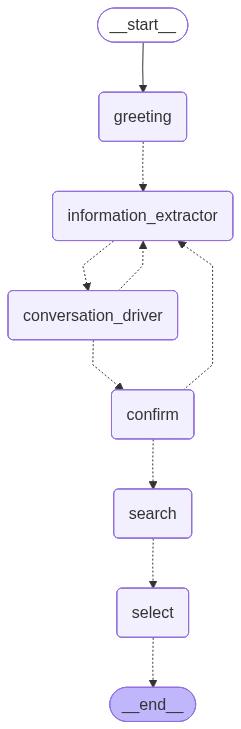

In [20]:
from IPython.display import Image, display

png_bytes = booking_graph.get_graph().draw_mermaid_png()
display(Image(data=png_bytes))